# Olist Delivery Analysis: Data Understanding

## 1. Project Analysis Scope

### Data Understanding and Analysis Scope

This notebook establishes the analytical scope for the Delivery
Performance and Customer Satisfaction Analysis.

The database has already been validated and transformed in PostgreSQL.
Therefore, this notebook does not repeat database-level data quality
checks.

Instead, it focuses on:

- identifying the population available for delivery analysis;
- understanding the analytical grain of the main tables;
- defining the time period used for trend analysis;
- establishing the core delivery metrics that will be used consistently
  throughout SQL, Python, and Power BI.

## 2. Imports and Database Connection

In [1]:
import os
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
env_path = project_root / ".env"

if not env_path.exists():
    raise FileNotFoundError(f".env file not found: {env_path}")

load_dotenv(env_path)

required_env_vars = [
    "POSTGRES_USER",
    "POSTGRES_PASSWORD",
    "POSTGRES_HOST",
    "POSTGRES_PORT",
    "POSTGRES_DATABASE",
]

missing_env_vars = [
    variable
    for variable in required_env_vars
    if not os.getenv(variable)
]

if missing_env_vars:
    raise EnvironmentError(
        f"Missing environment variables: {', '.join(missing_env_vars)}"
    )

postgres_url = URL.create(
    drivername="postgresql+psycopg2",
    username=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    host=os.getenv("POSTGRES_HOST"),
    port=int(os.getenv("POSTGRES_PORT")),
    database=os.getenv("POSTGRES_DATABASE"),
)

engine = create_engine(postgres_url)

connection_test = pd.read_sql(
    "SELECT current_database() AS database_name;",
    engine,
)

connection_test

,database_name
0,olist


## 3. Load Analysis Data

### Analysis Data

The analysis uses five core tables representing orders, customers,
products, order items, and customer reviews.

In [2]:
orders = pd.read_sql(
    "SELECT * FROM public.orders;",
    engine,
)

customers = pd.read_sql(
    "SELECT * FROM public.customers;",
    engine,
)

products = pd.read_sql(
    "SELECT * FROM public.products;",
    engine,
)

reviews = pd.read_sql(
    "SELECT * FROM public.order_reviews;",
    engine,
)

order_items = pd.read_sql(
    "SELECT * FROM public.order_items;",
    engine,
)

dataframes = {
    "orders": orders,
    "customers": customers,
    "products": products,
    "reviews": reviews,
    "order_items": order_items,
}

dataframe_overview = pd.DataFrame(
    {
        "dataframe": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
    }
    for name, df in dataframes.items()
)

dataframe_overview

,dataframe,rows,columns
0,orders,99441,8
1,customers,99441,5
2,products,32951,9
3,reviews,99224,7
4,order_items,112650,7


Only the tables required to define the analytical scope are loaded into
Pandas at this stage. Additional tables, such as payments, sellers, and
geolocation, will be incorporated later when they are needed for specific
business questions.

## 4. Analytical Grain

The main delivery analysis is performed at the order level because
delivery timestamps and estimated delivery dates are defined for each
order.

However, product, category, and seller attributes are stored at the
order-item level. Since one order may contain multiple items, joining
`orders` to `order_items` can create multiple rows for a single order.

In [3]:
items_per_order = (
    order_items.groupby("order_id")
    .size()
    .rename("item_count")
)

item_grain_summary = pd.DataFrame(
    {
        "orders_with_items": [items_per_order.size],
        "average_items_per_order": [items_per_order.mean()],
        "median_items_per_order": [items_per_order.median()],
        "multi_item_orders_pct": [
            items_per_order.gt(1).mean() * 100
        ],
        "maximum_items_per_order": [items_per_order.max()],
    }
)

item_grain_summary.round(2)

,orders_with_items,average_items_per_order,median_items_per_order,multi_item_orders_pct,maximum_items_per_order
0,98666,1.14,1.0,9.94,21


Most orders contain a single item, but approximately 9.94% contain
multiple item rows and the largest order contains 21 items.

Therefore, order-level delivery KPIs will be calculated from the
`orders` table. Product-, category-, and seller-level analyses will
account for the one-to-many relationship with `order_items` to avoid
double-counting orders.

## 5. Analytical Population

### Dataset date range

In [4]:
date_range = pd.DataFrame(
    {
        "first_purchase": [orders["order_purchase_timestamp"].min()],
        "last_purchase": [orders["order_purchase_timestamp"].max()],
        "first_delivery": [orders["order_delivered_customer_date"].min()],
        "last_delivery": [orders["order_delivered_customer_date"].max()],
    }
)

date_range

,first_purchase,last_purchase,first_delivery,last_delivery
0,2016-09-04 21:15:19,2018-10-17 17:30:18,2016-10-11 13:46:32,2018-10-17 13:22:46


The dataset contains purchases recorded between September 4, 2016,
and October 17, 2018.

The completeness of the first and final observation periods will be
evaluated before monthly trend analysis.

### Order status distribution

Order status is reviewed to determine which records represent completed
deliveries and can therefore be included in delivery-time calculations.

In [5]:
order_status = (
    orders["order_status"]
    .value_counts()
    .rename_axis("order_status")
    .reset_index(name="order_count")
)

order_status["percentage"] = (
    order_status["order_count"]
    .div(len(orders))
    .mul(100)
    .round(2)
)

order_status

,order_status,order_count,percentage
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


Delivered orders account for 97.02% of all order records, making them
the dominant population for delivery performance analysis.

The remaining statuses represent orders that were canceled, unavailable,
still being processed, or had not yet reached the customer. These records
cannot be used to calculate completed delivery duration.

### Missing values relevant to analysis

Only missing values that directly affect the definition of the analytical
population are reviewed here. Broader data-quality checks were completed
earlier in PostgreSQL.

In [6]:
missing_values = pd.DataFrame(
    {
        "total_orders": [len(orders)],
        "missing_approval_timestamp": [
            orders["order_approved_at"].isna().sum()
        ],
        "missing_carrier_timestamp": [
            orders["order_delivered_carrier_date"].isna().sum()
        ],
        "missing_customer_delivery_timestamp": [
            orders["order_delivered_customer_date"].isna().sum()
        ],
    }
)

missing_values

,total_orders,missing_approval_timestamp,missing_carrier_timestamp,missing_customer_delivery_timestamp
0,99441,160,1783,2965


Missing delivery timestamps are largely explained by orders that were
not completed. Therefore, missing customer delivery dates are not treated
as random data loss.

The approval and carrier timestamps require separate handling because
some delivered orders also lack these values. Such orders remain valid
for overall delivery analysis but cannot be used to calculate every
delivery stage.

In [7]:
missing_product_categories = (
    products["product_category_name"]
    .isna()
    .sum()
)

missing_product_categories

np.int64(610)

A total of 610 products have no assigned category. These records will
remain in the dataset and will be grouped as `Unknown` when category-level
analysis is performed.

### Analytical population

Based on order status and timestamp availability, separate analytical
populations are defined for overall delivery performance and for
stage-level delivery analysis.

In [8]:
analytical_population = pd.DataFrame(
    {
        "population": [
            "All orders",
            "Delivered orders",
            "Main delivery analysis",
            "Complete stage analysis",
        ],
        "order_count": [
            len(orders),
            (orders["order_status"] == "delivered").sum(),
            (
                (orders["order_status"] == "delivered")
                & orders["order_delivered_customer_date"].notna()
                & orders["order_estimated_delivery_date"].notna()
            ).sum(),
            (
                (orders["order_status"] == "delivered")
                & orders["order_approved_at"].notna()
                & orders["order_delivered_carrier_date"].notna()
                & orders["order_delivered_customer_date"].notna()
            ).sum(),
        ],
    }
)

analytical_population

,population,order_count
0,All orders,99441
1,Delivered orders,96478
2,Main delivery analysis,96470
3,Complete stage analysis,96455


The main delivery-performance population contains 96,470 delivered
orders with both an actual customer delivery timestamp and an estimated
delivery date.

A slightly smaller subset of 96,455 orders contains the complete
approval, carrier handoff, and customer delivery timeline required for
stage-level analysis.

This approach preserves valid delivered orders whenever possible instead
of excluding them simply because a timestamp required for a more specific
analysis is missing.

## 6. Customer Satisfaction Availability

Customer satisfaction will be measured using the numeric review score.
Before using it in the main analysis, its availability and baseline
distribution are reviewed.

In [9]:
review_availability = pd.DataFrame({
    "total_reviews": [len(reviews)],
    "orders_with_reviews": [reviews["order_id"].nunique()],
    "missing_review_scores": [reviews["review_score"].isna().sum()],
})

review_availability

,total_reviews,orders_with_reviews,missing_review_scores
0,99224,98673,0


All review records contain a numeric review score, so no review observations
need to be excluded because of a missing score.

However, review coverage is not one-to-one with orders: 99,224 review
records correspond to 98,673 unique orders. The relationship between
orders and reviews will therefore be handled explicitly when customer
satisfaction is combined with delivery data.

In [10]:
review_score_distribution = (
    reviews["review_score"]
    .value_counts()
    .sort_index()
    .rename_axis("review_score")
    .reset_index(name="review_count")
)

review_score_distribution["percentage"] = (
    review_score_distribution["review_count"]
    .div(review_score_distribution["review_count"].sum())
    .mul(100)
    .round(2)
)

review_score_distribution

,review_score,review_count,percentage
0,1,11424,11.51
1,2,3151,3.18
2,3,8179,8.24
3,4,19142,19.29
4,5,57328,57.78


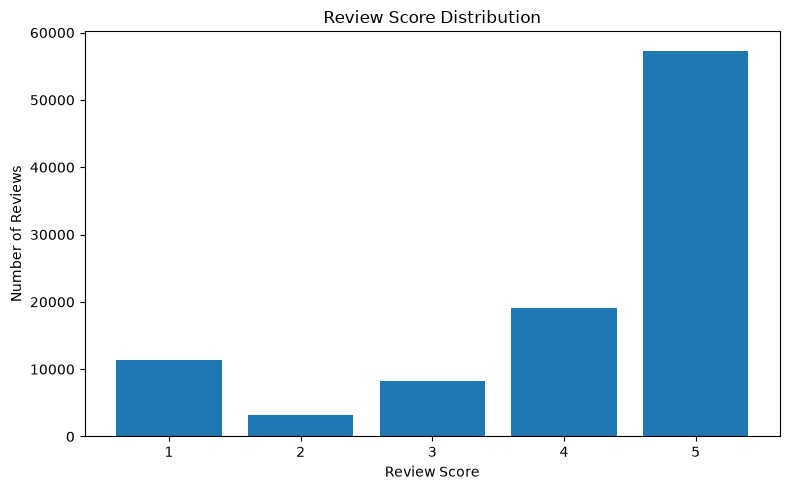

In [11]:
plt.figure(figsize=(8, 5))
plt.bar(
    review_score_distribution["review_score"],
    review_score_distribution["review_count"],
)
plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.xticks(review_score_distribution["review_score"])
plt.tight_layout()
plt.show()

Scores are strongly concentrated at the upper end of the scale, with
57.78% of reviews receiving the maximum score of 5.

This distribution provides the baseline against which review outcomes
for on-time and delayed deliveries will later be compared.

## 7. Core metrics definitions

The following metric definitions establish a consistent calculation
framework for the SQL business queries, Python exploratory analysis, and
Power BI dashboard.

- **Delivery time (`delivery_days`)**  
  Time between purchase and customer delivery:

  `order_delivered_customer_date - order_purchase_timestamp`

- **Seller processing time (`seller_processing_days`)**  
  Time between order approval and carrier handoff:

  `order_delivered_carrier_date - order_approved_at`

- **Carrier delivery time (`carrier_delivery_days`)**  
  Time between carrier handoff and customer delivery:

  `order_delivered_customer_date - order_delivered_carrier_date`

- **Delay (`delay_days`)**  
  Difference in calendar days between the actual customer delivery date
  and the estimated delivery date. Positive values indicate late delivery,
  while zero or negative values indicate on-time or early delivery.

- **Late delivery (`is_late`)**  
  `True` when the actual delivery date is later than the estimated
  delivery date.

## 8. Data understanding summary

### Data Understanding Summary

The exploratory and business analysis will follow the rules established
in this notebook:

- delivery KPIs will be calculated primarily at the **order level**;
- the main delivery-performance population contains **96,470 delivered
  orders** with both actual and estimated delivery dates;
- the dataset covers purchases from September 2016 to October 2018,
  while the completeness of boundary periods will be assessed before
  monthly trend analysis;
- delivery-stage analysis will use the **96,455 orders** with complete
  approval, carrier handoff, and customer delivery timestamps;
- joins to product, category, and seller data will account for the
  one-to-many relationship between orders and order items;
- customer satisfaction will be measured using the numeric
  `review_score`, which contains no missing values;
- products without category information will be retained as `Unknown`
  in category-level analysis;
- delivery time, processing time, carrier time, delay, and late-delivery
  status will follow the metric definitions specified above.